In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import pingouin as pg
import numpy as np
from webpower.power_tests import wp_rmanova_test
import sklearn as sk
from scipy.stats import boxcox
from scipy.stats import rankdata


**Loading of data**


In [2]:
# Replace with our file path
df = pd.read_csv("ai_grading_final.csv")
# Required columns:
required_columns = [
    "answer_key_id",
    "true_mistakes",
    "prompt_type",
    "ai_estimated_mistakes"
]
df = df.dropna()
# Dependent variable: AI grading error
df["ai_error"] = df["ai_estimated_mistakes"] - df["true_mistakes"]
df["Absolute_error"] = abs(df["ai_estimated_mistakes"]-df["true_mistakes"])

df["true_mistakes"] = df["true_mistakes"].astype("category")
df["prompt_type"] = df["prompt_type"].astype("category")

In [3]:
shift = df["ai_error"].min()
print(shift)
counts_shifted = df["ai_error"] - shift + 1
ai_error_n, opt_lambda = boxcox(counts_shifted)
df["ai_error_n"]=ai_error_n
df["ai_error_n_ranked"] = rankdata(df["ai_error_n"])

shift2 = df["Absolute_error"].min()
print(shift2)
counts_shifted = df["Absolute_error"] - shift2 + 1
ai_absolute_n, opt_lambda = boxcox(counts_shifted)
df["ai_absolute_n"]=ai_absolute_n


-5
0


**2-way Mixed ANOVA**

Assumptions: Homogeneity of variance, Independence of observations, Normally-distributed dependent variable 


ANOVA SUMMARY

Source              SS    DF1    DF2      MS       F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  -------  -----  -----  ------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes  107.281      7    295  15.326  16.394    0.000      nan      0.280  nan           nan        nan        nan
prompt_type     33.631      4   1180   8.408  10.402    0.000        0.000  0.034    0.698         0.000      0.495      0.000
Interaction     35.375     28   1180   1.263   1.563    0.032      nan      0.036  nan           nan        nan        nan



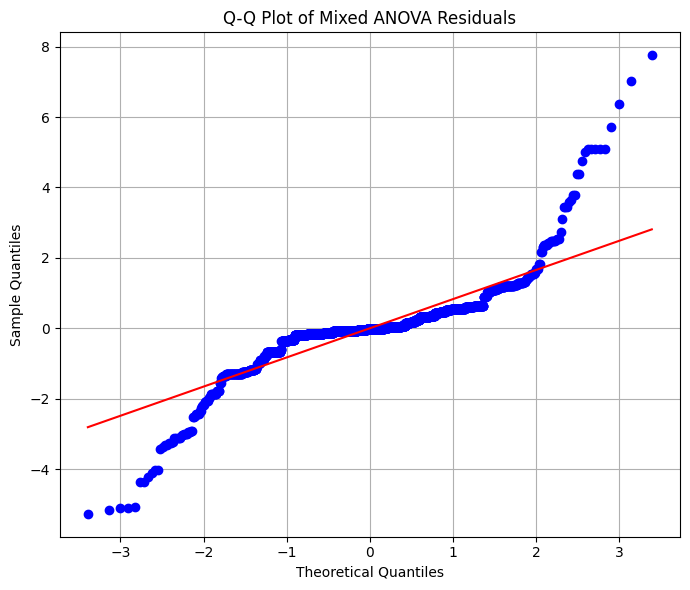

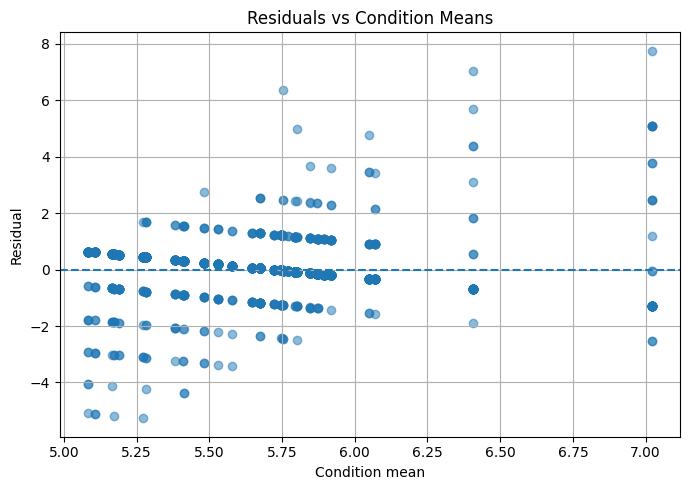

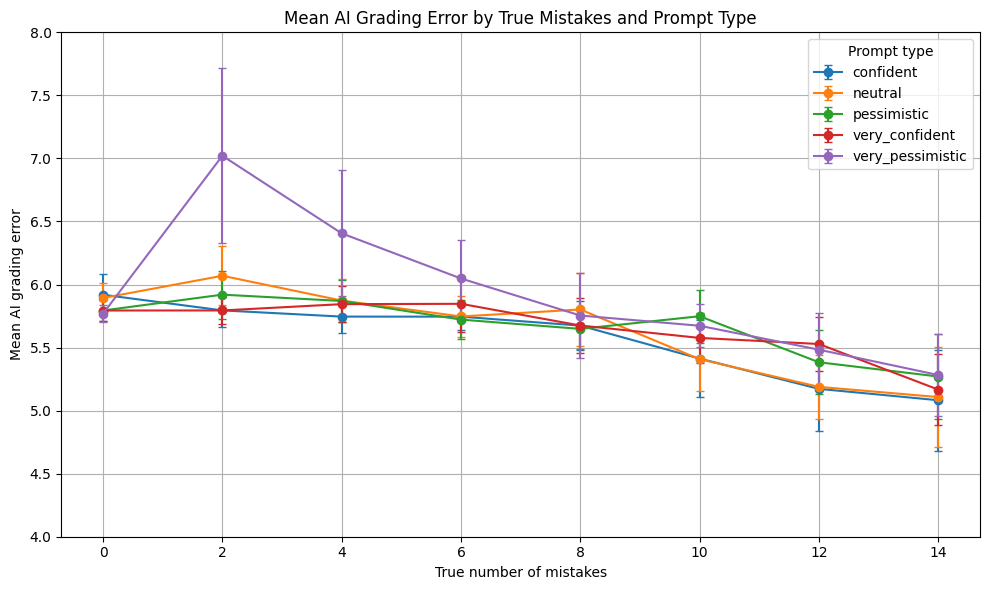

In [4]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="ai_error_n",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["ai_error_n"].transform("mean")

df["anova_residual"] = df["ai_error_n"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means
#How far is this specific observation from the average result in the same condition? 
# One specific combination of true error level and prompt type.
#Condition means is the average value for each experimental condition.

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error_n", "mean"),
        sd_ai_error=("ai_error_n", "std"),
        n=("ai_error_n", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )
plt.ylim(4, 8)
plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


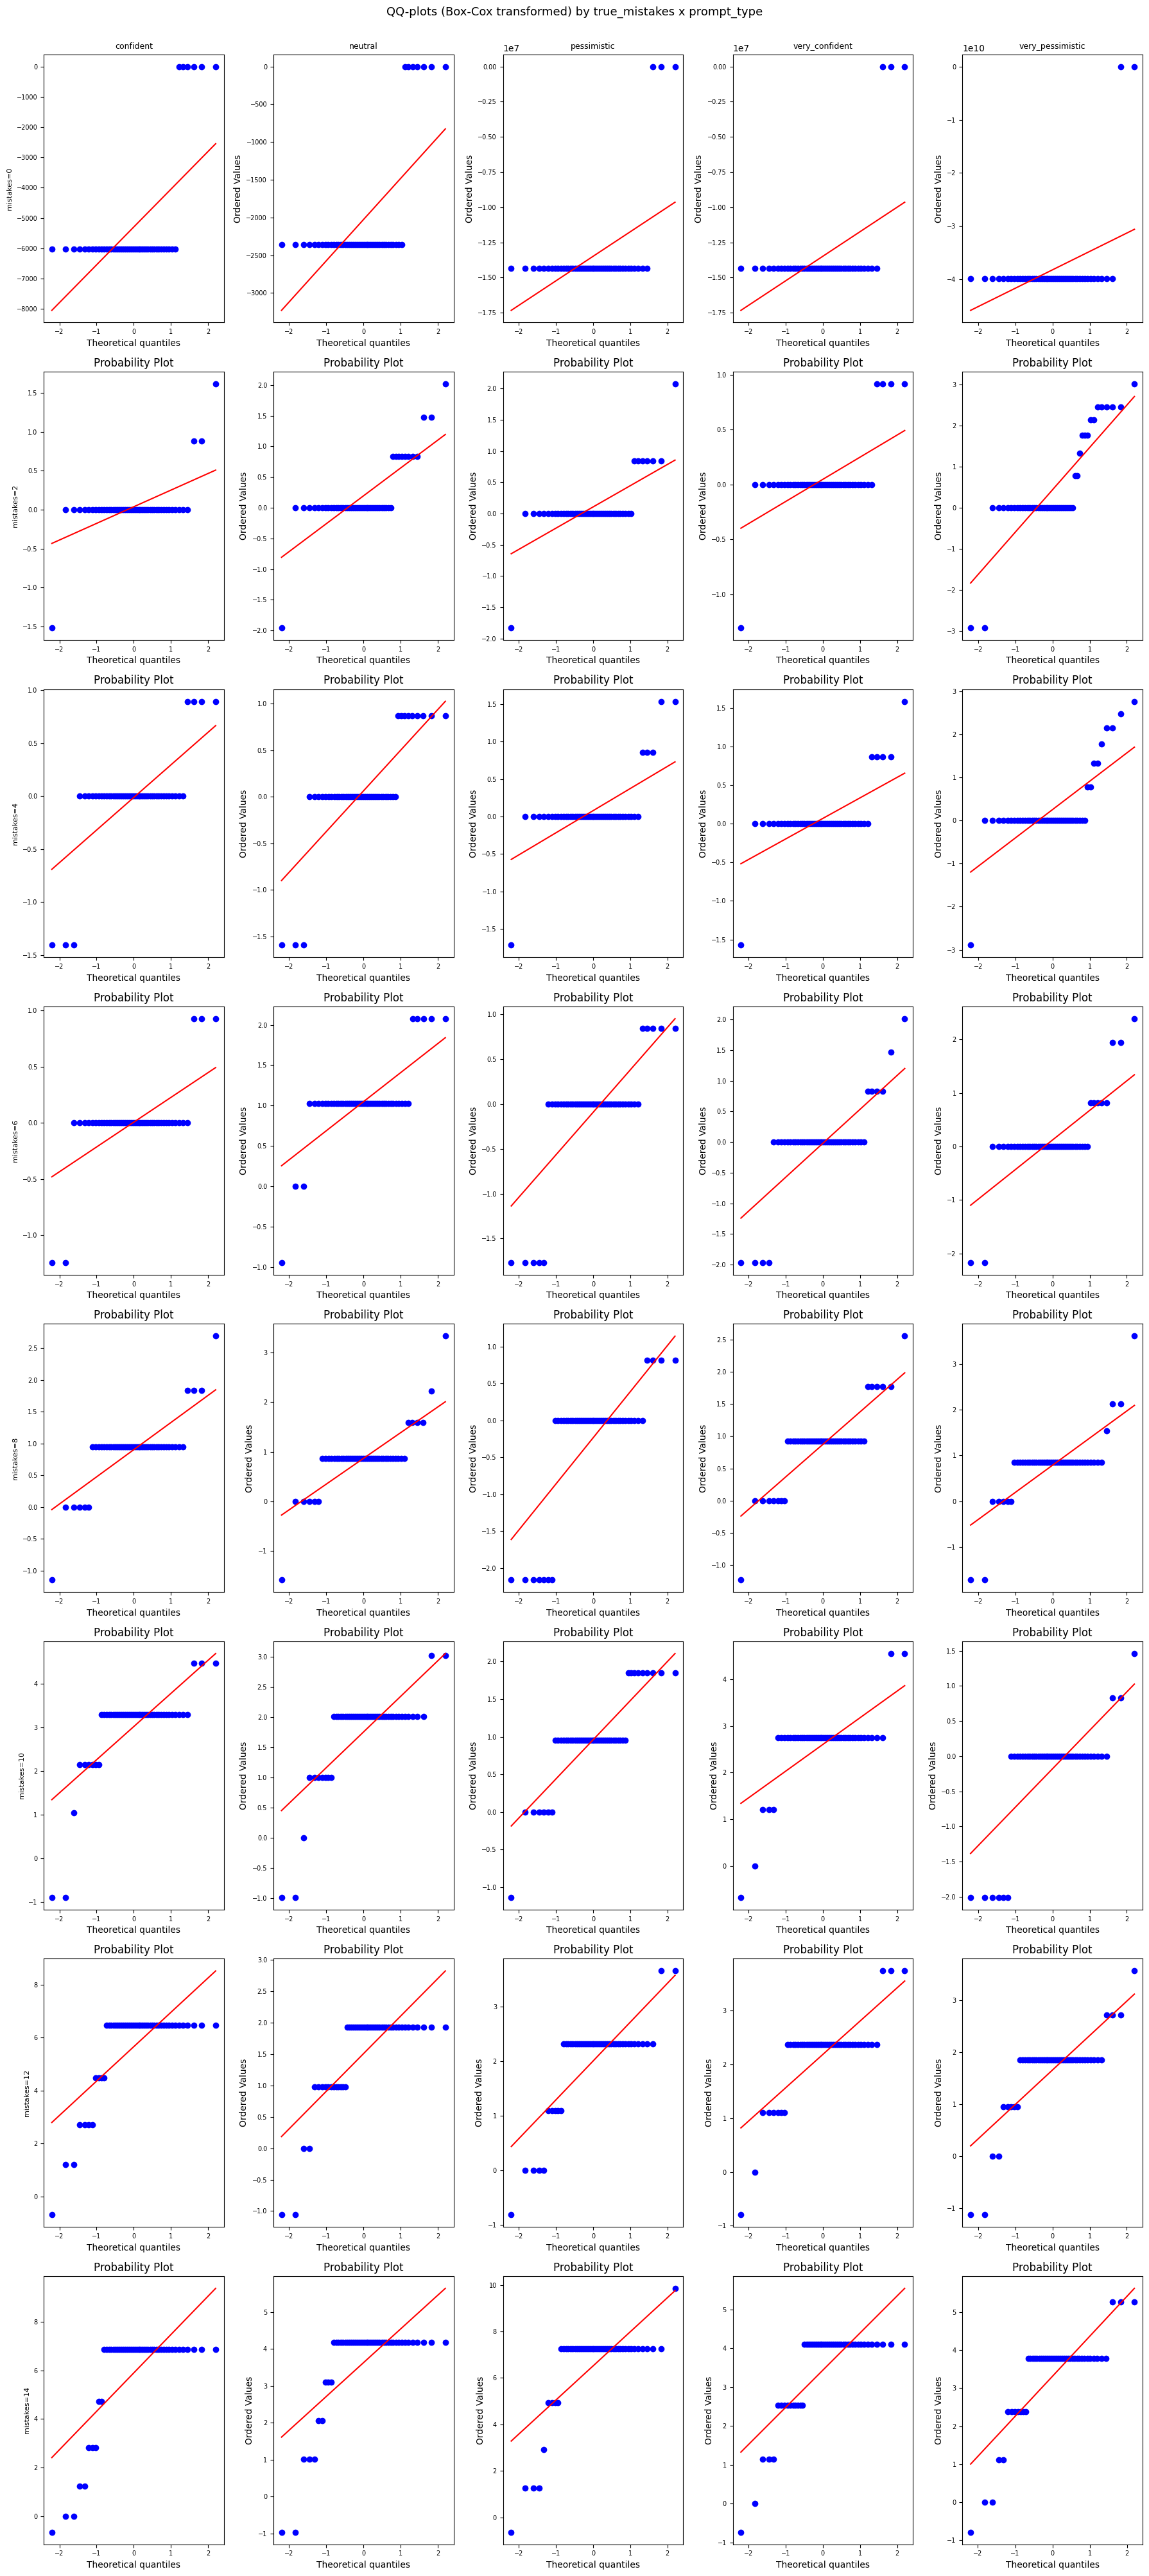

Sample of Box-Cox parameters:
(0, 'confident') {'lambda': np.float64(-0.5920417407160963), 'shift': np.float64(1e-06)}
(0, 'neutral') {'lambda': np.float64(-0.5139884957254528), 'shift': np.float64(1e-06)}
(0, 'pessimistic') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_confident') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_pessimistic') {'lambda': np.float64(-1.809560235155417), 'shift': np.float64(1e-06)}


In [16]:
# qq plot matrix (with optional Box-Cox)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

matrix = df.groupby(["true_mistakes", "prompt_type"])["ai_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

print("Sample of Box-Cox parameters:")
for k, v in list(lambda_table.items())[:5]:
    print(k, v)

**ABSOLUTE ERROR VERSION**


ANOVA SUMMARY

Source             SS    DF1    DF2     MS      F    p_unc    p_GG_corr    np2      eps    sphericity    W_spher    p_spher
-------------  ------  -----  -----  -----  -----  -------  -----------  -----  -------  ------------  ---------  ---------
true_mistakes   7.756      7    295  1.108  2.127    0.041      nan      0.048  nan           nan        nan        nan
prompt_type    12.640      4   1180  3.160  6.346    0.000        0.000  0.021    0.720         0.000      0.528      0.000
Interaction    25.120     28   1180  0.897  1.802    0.007      nan      0.041  nan           nan        nan        nan



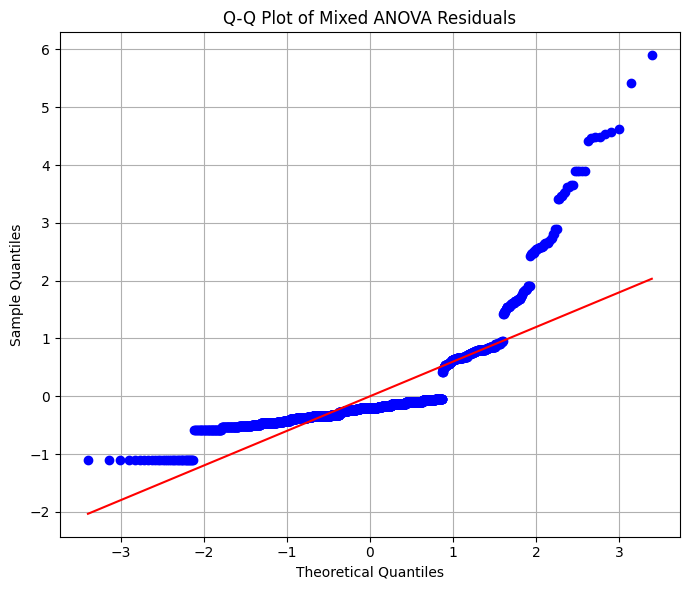

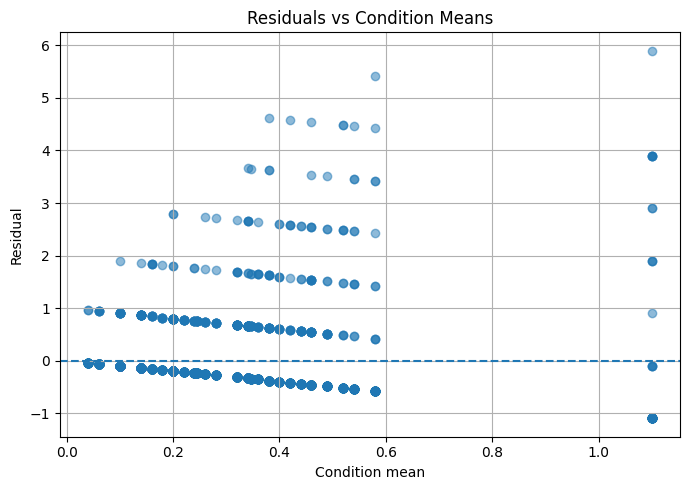

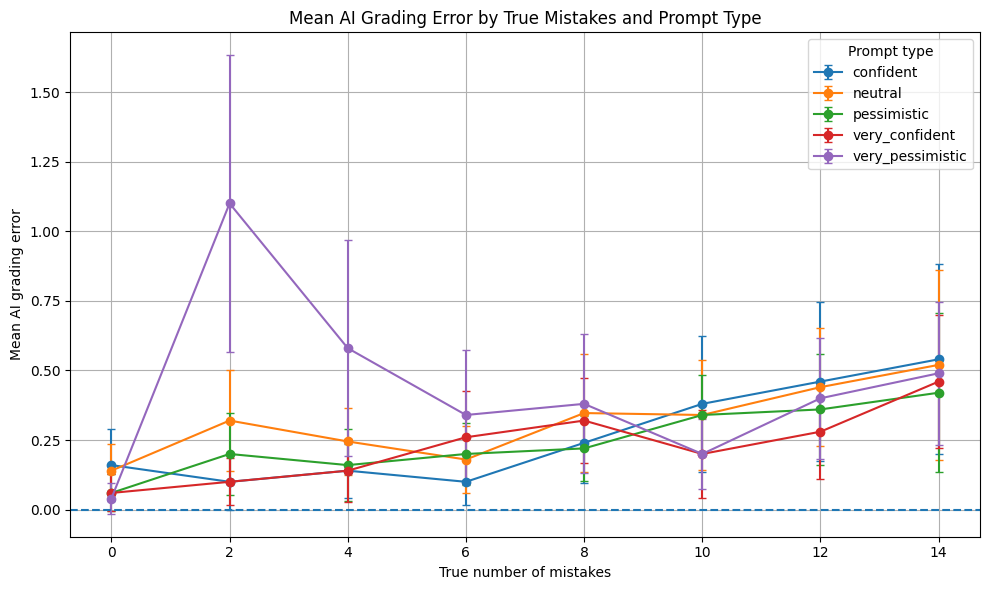

In [6]:
mixed_anova = pg.mixed_anova(
    data=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

pg.print_table(mixed_anova)

# 10. Q-Q plot of residual-like centered scores

df["cell_mean"] = df.groupby(
    ["true_mistakes", "prompt_type"],
    observed=False
)["Absolute_error"].transform("mean")

df["anova_residual"] = df["Absolute_error"] - df["cell_mean"]

plt.figure(figsize=(7, 6))
stats.probplot(df["anova_residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Mixed ANOVA Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals vs condition means

plt.figure(figsize=(7, 5))
plt.scatter(df["cell_mean"], df["anova_residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Condition Means")
plt.xlabel("Condition mean")
plt.ylabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot mean AI error by true mistakes and prompt

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()

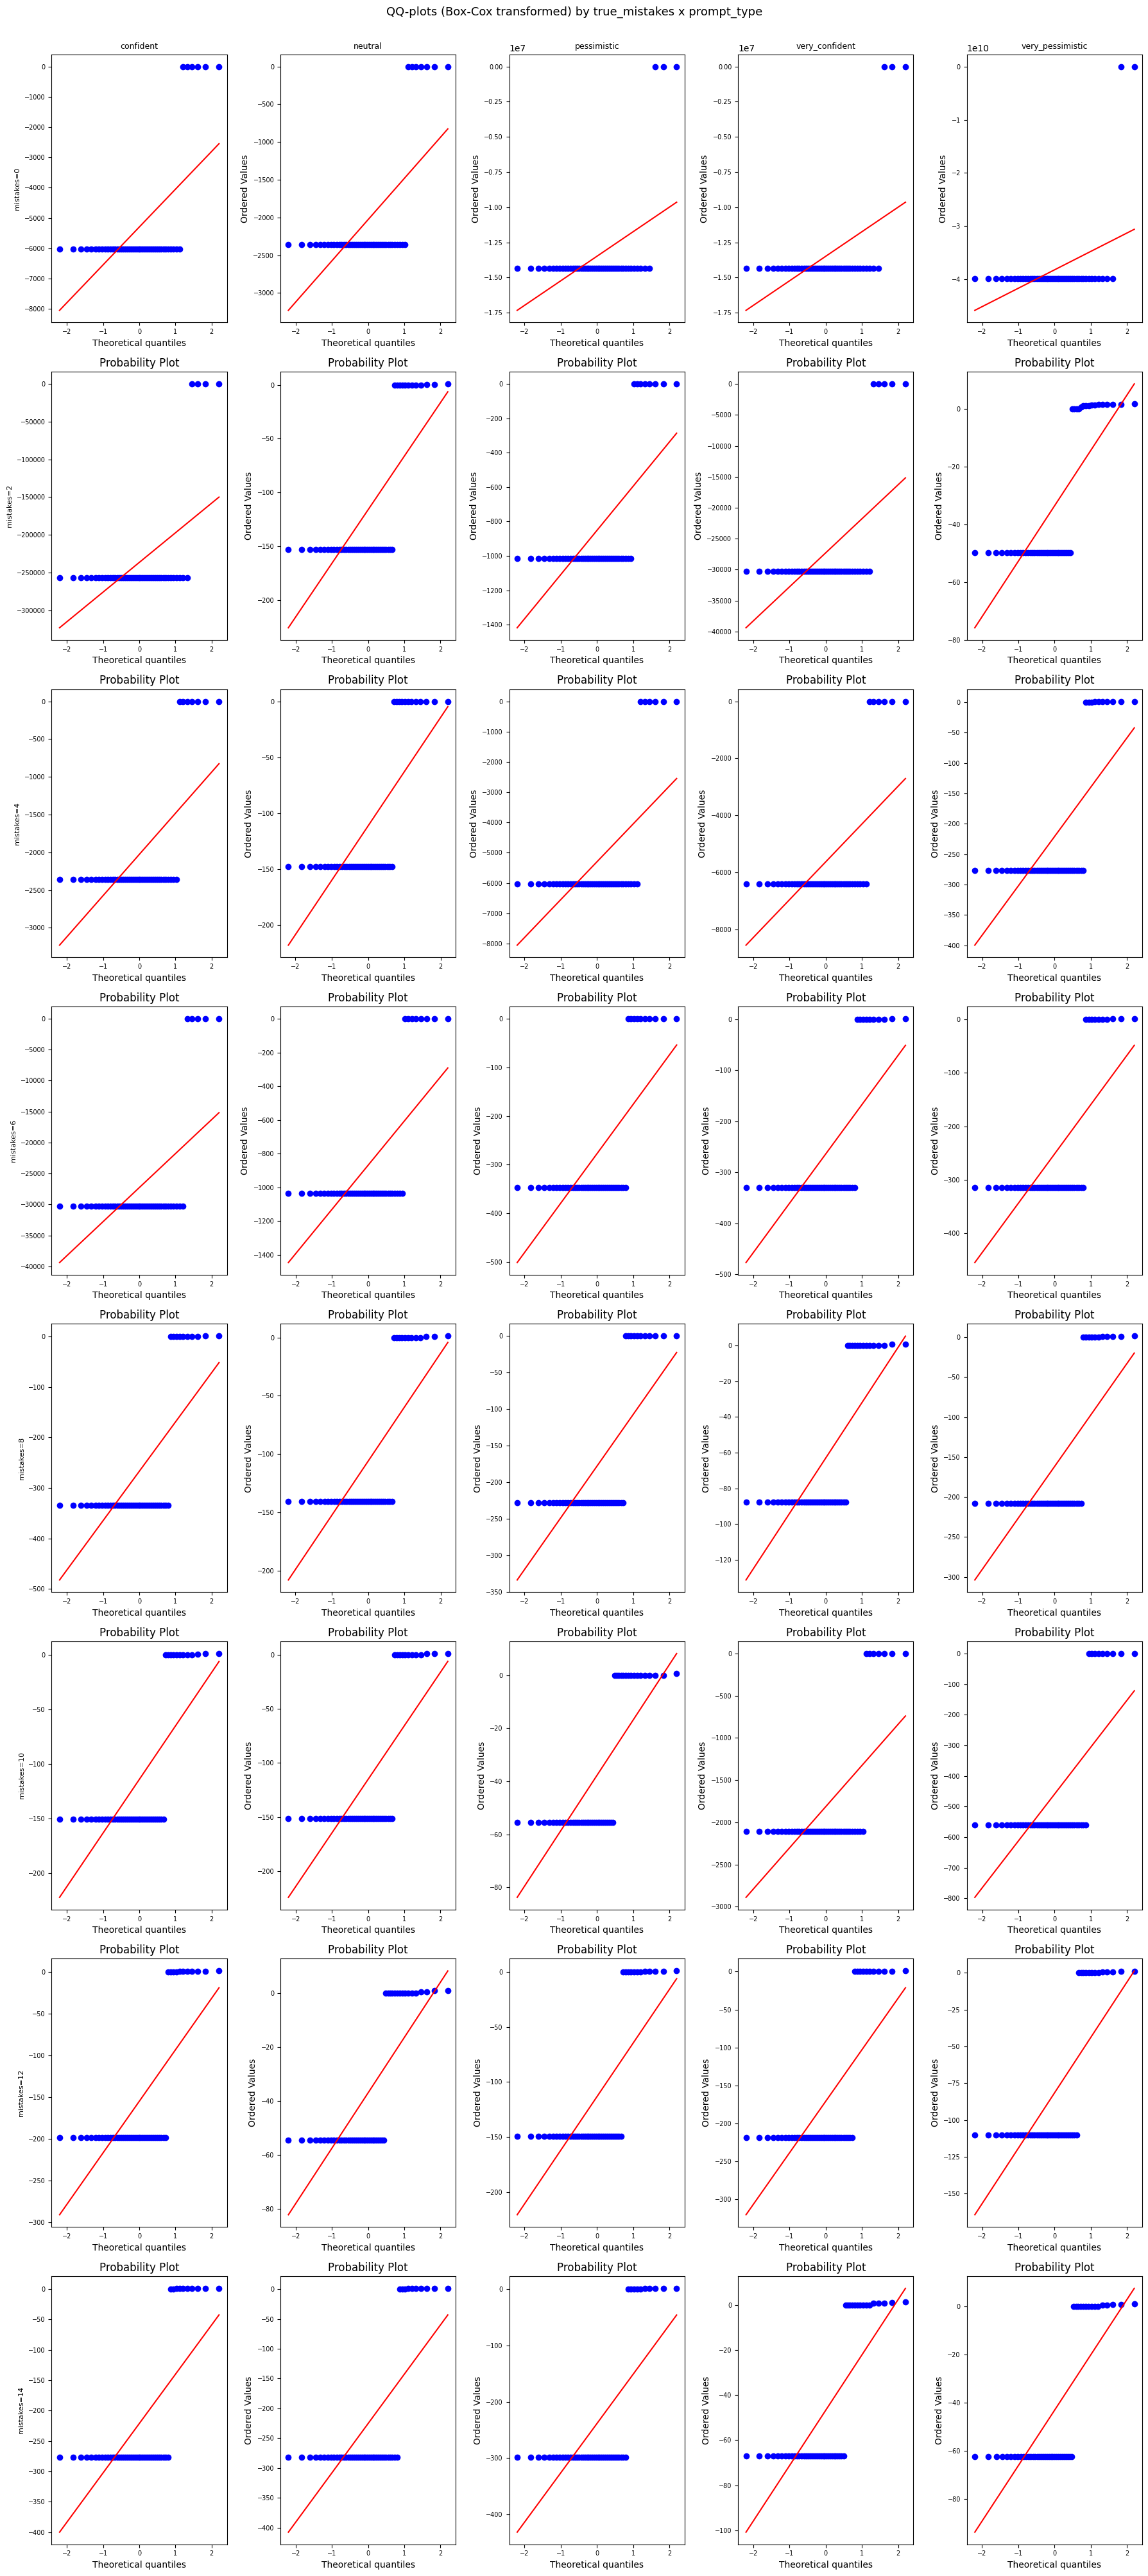

Sample of Box-Cox parameters:
(0, 'confident') {'lambda': np.float64(-0.5920417407160963), 'shift': np.float64(1e-06)}
(0, 'neutral') {'lambda': np.float64(-0.5139884957254528), 'shift': np.float64(1e-06)}
(0, 'pessimistic') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_confident') {'lambda': np.float64(-1.2063722871038725), 'shift': np.float64(1e-06)}
(0, 'very_pessimistic') {'lambda': np.float64(-1.809560235155417), 'shift': np.float64(1e-06)}


In [18]:
# qq plot matrix (with optional Box-Cox)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

matrix = df.groupby(["true_mistakes", "prompt_type"])["Absolute_error"].apply(np.array).unstack("prompt_type")

types = ["confident", "neutral", "pessimistic", "very_confident", "very_pessimistic"]
rows = matrix.index.tolist()  # expected 16 true_mistakes levels


def boxcox_residuals(x, eps=1e-6):
    x = np.asarray(x).ravel().astype(float)

    # Box-Cox requires strictly positive values; shift each vector if needed.
    shift = 1.0
    min_x = np.min(x)
    if min_x <= 0:
        shift = -min_x + eps

    x_pos = x + shift

    # Box-Cox also needs non-constant data.
    if np.allclose(x_pos, x_pos[0]):
        return None, np.nan, shift

    x_bc, lam = stats.boxcox(x_pos)
    return x_bc, lam, shift


fig, axes = plt.subplots(len(rows), len(types), figsize=(18, 40), squeeze=False)
lambda_table = {}

for r, tm in enumerate(rows):
    for c, prompt in enumerate(types):
        ax = axes[r, c]

        if prompt not in matrix.columns:
            ax.set_visible(False)
            continue

        res_raw = matrix.loc[tm, prompt]
        if not isinstance(res_raw, (np.ndarray, list, tuple)):
            ax.set_visible(False)
            continue

        res = np.asarray(res_raw).ravel()
        if res.size < 3:
            ax.set_visible(False)
            continue

        res_bc, lam, shift = boxcox_residuals(res)
        if res_bc is None:
            ax.set_visible(False)
            continue

        stats.probplot(res_bc, dist="norm", plot=ax)
        lambda_table[(tm, prompt)] = {"lambda": lam, "shift": shift}

        if r == 0:
            ax.set_title(prompt, fontsize=9)
        if c == 0:
            ax.set_ylabel(f"mistakes={tm}", fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("QQ-plots (Box-Cox transformed) by true_mistakes x prompt_type", y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

print("Sample of Box-Cox parameters:")
for k, v in list(lambda_table.items())[:5]:
    print(k, v)

Ikke normal fordelt så vi bruger ART

Verificering — aligned kolonner skal summe til ~0:
  Y'_A  sum: -0.000000
  Y'_B  sum: 0.000000
  Y'_AB sum: -0.000000

ANOVA SUMMARY

Source                  SS    DF1    DF2            MS          F    p_unc    p_GG_corr    np2    eps  sphericity      W_spher    p_spher
-----------  -------------  -----  -----  ------------  ---------  -------  -----------  -----  -----  ------------  ---------  ---------
prompt_type  327542915.154      4   1180  81885728.789  10406.839    0.000        0.000  0.972  0.483  False             0.106      0.000


ANOVA SUMMARY

Source                    SS    DF1    DF2            MS         F    p_unc    p_GG_corr    np2    eps    sphericity    W_spher    p_spher
-------------  -------------  -----  -----  ------------  --------  -------  -----------  -----  -----  ------------  ---------  ---------
true_mistakes  414546235.687      7    295  59220890.812  1851.358    0.000          nan  0.978    nan           nan        nan        nan


ANOVA SUMMARY



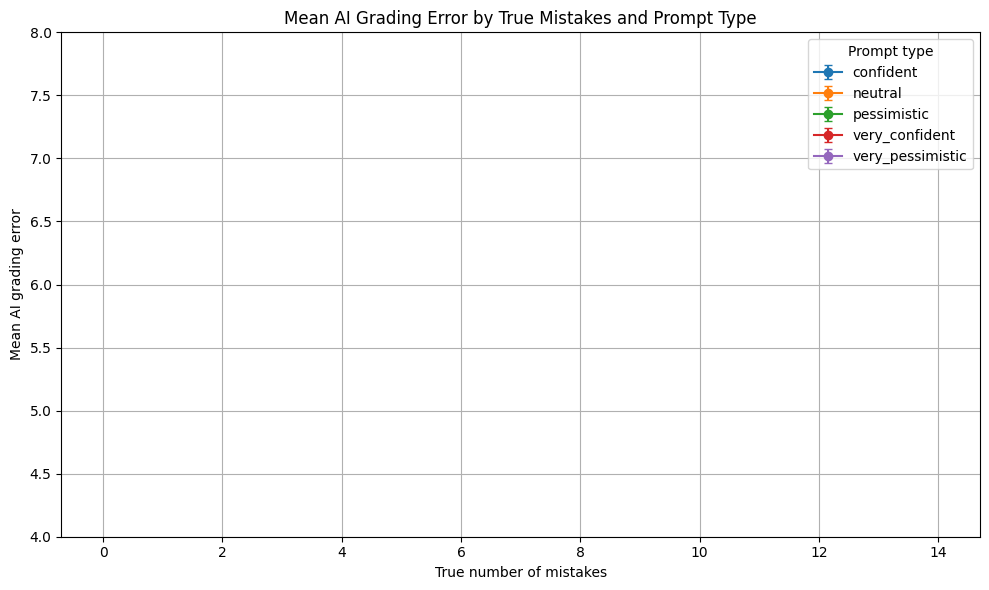

In [10]:
def aligned_rank_transform(df, dv, within, between, subject):
    df = df.copy()
    df[within]  = df[within].astype(str)
    df[between] = df[between].astype(str)

    grand_mean = df[dv].mean()

    mean_A   = df.groupby(within,  observed=True)[dv].transform("mean")  # Ā_i
    mean_B   = df.groupby(between, observed=True)[dv].transform("mean")  # B̄_j
    mean_AB  = df.groupby([within, between], observed=True)[dv].transform("mean")  # ĀB̄_ij

    # Trin 1: Beregn residualer 
    cell_mean = df.groupby([subject, within, between], observed=True)[dv].transform("mean")
    # finder alle forskellige kombier af key_id, prompt_type og true mistakes, finder gennemsnittet af ai error for de forskellige kombier, sætter gennemsnittet ind på de forskellige kombier.  
    residual  = df[dv] - cell_mean


    # Trin 2 beregn effekt
    # Effekt A (within / prompt_type):      Ā_i - µ
    effect_A   = mean_A - grand_mean

    # Effekt B (between / true_mistakes):   B̄_j - µ
    effect_B   = mean_B - grand_mean

    # Effekt A*B (interaktion):             ĀB̄_ij - Ā_i - B̄_j + µ
    effect_AB  = mean_AB - mean_A - mean_B + grand_mean


    #Trin 3: Aligned response Y' = residual + estimeret effekt 
    df["Y_prime_A"]  = residual + effect_A
    df["Y_prime_B"]  = residual + effect_B
    df["Y_prime_AB"] = residual + effect_AB

    #Trin 4: Rang Y' → Y''
    df["Y_ranked_A"]  = rankdata(df["Y_prime_A"])
    df["Y_ranked_B"]  = rankdata(df["Y_prime_B"])
    df["Y_ranked_AB"] = rankdata(df["Y_prime_AB"])

    # Ensuring correctness
    print("Verificering — aligned kolonner skal summe til ~0:")
    print(f"  Y'_A  sum: {df['Y_prime_A'].sum():.6f}")
    print(f"  Y'_B  sum: {df['Y_prime_B'].sum():.6f}")
    print(f"  Y'_AB sum: {df['Y_prime_AB'].sum():.6f}")

    return df

df_art = aligned_rank_transform(
    df=df,
    dv="ai_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

#Trin 5: Kør Mixed ANOVA på Y'' for hver effekt
res_A = pg.mixed_anova(
    data=df_art, dv="Y_ranked_A",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_A[res_A["Source"] == "prompt_type"])

res_B = pg.mixed_anova(
    data=df_art, dv="Y_ranked_B",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_B[res_B["Source"] == "true_mistakes"])


res_AB = pg.mixed_anova(
    data=df_art, dv="Y_ranked_AB",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_AB[res_AB["Source"] == "Interaction"])


#GRAF

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("ai_error", "mean"),
        sd_ai_error=("ai_error", "std"),
        n=("ai_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )
plt.ylim(4, 8)
plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_prompts = pg.pairwise_tests(
    data=df_art,
    dv="ai_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)

posthoc_true_mistakes = pg.pairwise_tests(
    data=df_art,
    dv="ai_error",
    between="true_mistakes",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)
print(posthoc_true_mistakes)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T    dof alternative     p_unc    p_corr p_adjust      BF10  \
0 -1.284328  302.0   two-sided  0.200011  0.800046     holm     0.145   
1 -2.213161  302.0   two-sided  0.027634  0.165804     holm  

Verificering — aligned kolonner skal summe til ~0:
  Y'_A  sum: -0.000000
  Y'_B  sum: -0.000000
  Y'_AB sum: 0.000000

ANOVA SUMMARY

Source                  SS    DF1    DF2            MS         F    p_unc    p_GG_corr    np2    eps  sphericity      W_spher    p_spher
-----------  -------------  -----  -----  ------------  --------  -------  -----------  -----  -----  ------------  ---------  ---------
prompt_type  292133392.119      4   1180  73033348.030  9679.643    0.000        0.000  0.970  0.513  False             0.084      0.000


ANOVA SUMMARY

Source                    SS    DF1    DF2            MS         F    p_unc    p_GG_corr    np2    eps    sphericity    W_spher    p_spher
-------------  -------------  -----  -----  ------------  --------  -------  -----------  -----  -----  ------------  ---------  ---------
true_mistakes  260176116.081      7    295  37168016.583  1186.118    0.000          nan  0.966    nan           nan        nan        nan


ANOVA SUMMARY

Sou

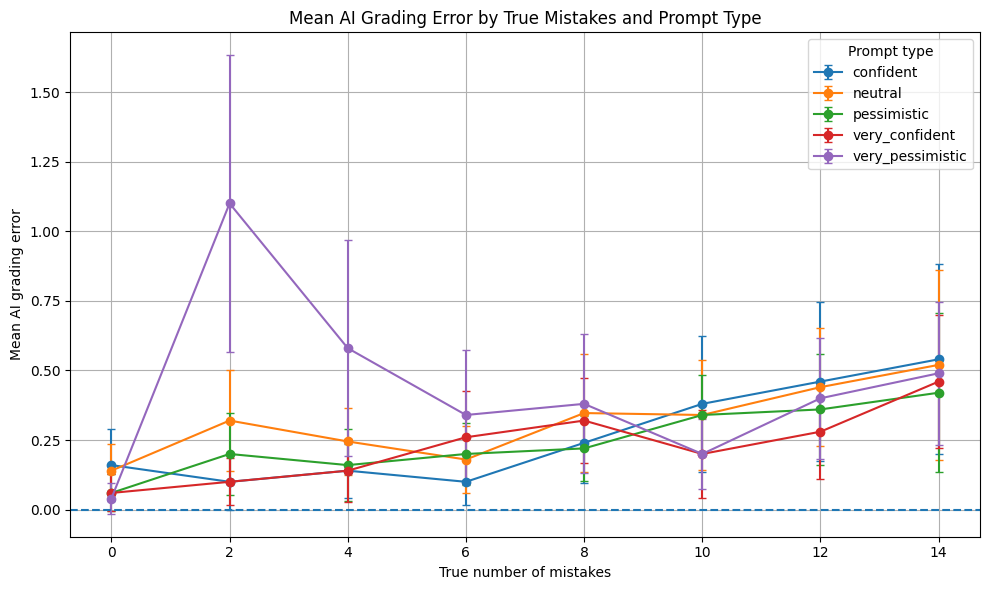

In [12]:
from scipy.stats import rankdata

def aligned_rank_transform(df, dv, within, between, subject):
    df = df.copy()
    df[within]  = df[within].astype(str)
    df[between] = df[between].astype(str)

    grand_mean = df[dv].mean()

    mean_A   = df.groupby(within,  observed=True)[dv].transform("mean")  # Ā_i
    mean_B   = df.groupby(between, observed=True)[dv].transform("mean")  # B̄_j
    mean_AB  = df.groupby([within, between], observed=True)[dv].transform("mean")  # ĀB̄_ij

    # Trin 1: Beregn residualer 
    cell_mean = df_art.groupby(["answer_key_id", "prompt_type", "true_mistakes"])["Absolute_error"].transform("mean")
    # finder alle forskellige kombier af key_id, prompt_type og true mistakes, finder gennemsnittet af ai error for de forskellige kombier, sætter gennemsnittet ind på de forskellige kombier.  
    residual  = df[dv] - cell_mean


    # Trin 2 beregn effekt
    # Effekt A (within / prompt_type):      Ā_i - µ
    effect_A   = mean_A - grand_mean

    # Effekt B (between / true_mistakes):   B̄_j - µ
    effect_B   = mean_B - grand_mean

    # Effekt A*B (interaktion):             ĀB̄_ij - Ā_i - B̄_j + µ
    effect_AB  = mean_AB - mean_A - mean_B + grand_mean


    #Trin 3: Aligned response Y' = residual + estimeret effekt 
    df["Y_prime_A"]  = residual + effect_A
    df["Y_prime_B"]  = residual + effect_B
    df["Y_prime_AB"] = residual + effect_AB

    #Trin 4: Rang Y' → Y''
    df["Y_ranked_A"]  = rankdata(df["Y_prime_A"])
    df["Y_ranked_B"]  = rankdata(df["Y_prime_B"])
    df["Y_ranked_AB"] = rankdata(df["Y_prime_AB"])

    # Ensuring correctness
    print("Verificering — aligned kolonner skal summe til ~0:")
    print(f"  Y'_A  sum: {df['Y_prime_A'].sum():.6f}")
    print(f"  Y'_B  sum: {df['Y_prime_B'].sum():.6f}")
    print(f"  Y'_AB sum: {df['Y_prime_AB'].sum():.6f}")

    return df

df_art = aligned_rank_transform(
    df=df,
    dv="Absolute_error",
    within="prompt_type",
    between="true_mistakes",
    subject="answer_key_id"
)

#Trin 5: Kør Mixed ANOVA på Y'' for hver effekt
res_A = pg.mixed_anova(
    data=df_art, dv="Y_ranked_A",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_A[res_A["Source"] == "prompt_type"])

res_B = pg.mixed_anova(
    data=df_art, dv="Y_ranked_B",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_B[res_B["Source"] == "true_mistakes"])


res_AB = pg.mixed_anova(
    data=df_art, dv="Y_ranked_AB",
    within="prompt_type", between="true_mistakes",
    subject="answer_key_id"
)
pg.print_table(res_AB[res_AB["Source"] == "Interaction"])


#GRAF

summary = (
    df.groupby(["true_mistakes", "prompt_type"], observed=False)
    .agg(
        mean_ai_error=("Absolute_error", "mean"),
        sd_ai_error=("Absolute_error", "std"),
        n=("Absolute_error", "count")
    )
    .reset_index()
)

summary["se_ai_error"] = summary["sd_ai_error"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["se_ai_error"]
summary["true_mistakes_numeric"] = summary["true_mistakes"].astype(int)

plt.figure(figsize=(10, 6))

for prompt in summary["prompt_type"].unique():
    subset = summary[summary["prompt_type"] == prompt]

    plt.errorbar(
        subset["true_mistakes_numeric"],
        subset["mean_ai_error"],
        yerr=subset["ci95"],
        marker="o",
        capsize=3,
        label=str(prompt)
    )

plt.axhline(0, linestyle="--")
plt.title("Mean AI Grading Error by True Mistakes and Prompt Type")
plt.xlabel("True number of mistakes")
plt.ylabel("Mean AI grading error")
plt.legend(title="Prompt type")
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
# Post-hoc tests between prompts
# Since prompt_type is a repeated-measures factor, comparisons between prompts should be paired t-tests with holm-correction.

posthoc_abs_prompts = pg.pairwise_tests(
    data=df_art,
    dv="Absolute_error",
    within="prompt_type",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)

print(posthoc_prompts)

posthoc_abs_true_mistakes = pg.pairwise_tests(
    data=df_art,
    dv="Absolute_error",
    between="true_mistakes",
    subject="answer_key_id",
    parametric=True,
    padjust="holm",
    effsize="hedges"
)
print(posthoc_true_mistakes)


      Contrast               A                 B  Paired  Parametric  \
0  prompt_type       confident           neutral    True        True   
1  prompt_type       confident       pessimistic    True        True   
2  prompt_type       confident    very_confident    True        True   
3  prompt_type       confident  very_pessimistic    True        True   
4  prompt_type         neutral       pessimistic    True        True   
5  prompt_type         neutral    very_confident    True        True   
6  prompt_type         neutral  very_pessimistic    True        True   
7  prompt_type     pessimistic    very_confident    True        True   
8  prompt_type     pessimistic  very_pessimistic    True        True   
9  prompt_type  very_confident  very_pessimistic    True        True   

          T    dof alternative     p_unc    p_corr p_adjust      BF10  \
0 -1.284328  302.0   two-sided  0.200011  0.800046     holm     0.145   
1 -2.213161  302.0   two-sided  0.027634  0.165804     holm  

Nu til sample size test for endelig forsøg

In [14]:
# Bonferroni-korrektion for 10 sammenligninger
alpha_corrected = 0.05 / 10

results = posthoc_abs_prompts.copy()
# Cohen's dz fra paired t-test
results["dz"] = (
    results["T"].abs()
    / np.sqrt(results["dof"] + 1)
)

# Beregn nødvendigt antal par / answer sheets
results["required_n"] = results["dz"].apply(
    lambda dz: np.ceil(
        pg.power_ttest(
            d=dz,
            n=None,
            power=0.80,
            alpha=alpha_corrected,
            contrast="paired",
            alternative="two-sided"
            ))).astype(int)

display(results[["A", "B", "T", "dz", "required_n"]])

alpha_corrected2=0.05/28
results2=posthoc_abs_true_mistakes.copy()

results2["dz"] = (
    results2["T"].abs()
    / np.sqrt(results2["dof"] + 1)
)

# Beregn nødvendigt antal par / answer sheets
results2["required_n"] = results2["dz"].apply(
    lambda dz: np.ceil(
        pg.power_ttest(
            d=dz,
            n=None,
            power=0.80,
            alpha=alpha_corrected2,
            contrast="two-samples",
            alternative="two-sided"
            ))).astype(int)

display(results2[["A", "B", "T", "dz", "required_n"]])


print(
    "Maximum required answer sheets:",
    results["required_n"].max()
)

print(
    "Maximum required answer sheets:",
    results2["required_n"].max()
)

,A,B,T,dz,required_n
0,confident,neutral,-1.376672,0.079088,2133
1,confident,pessimistic,0.086485,0.004968,539298
2,confident,very_confident,0.611595,0.035135,10788
3,confident,very_pessimistic,-2.937414,0.168750,472
4,neutral,pessimistic,1.537023,0.088300,1712
5,neutral,very_confident,2.114489,0.121474,907
6,neutral,very_pessimistic,-2.217577,0.127396,825
7,pessimistic,very_confident,0.612132,0.035166,10770
8,pessimistic,very_pessimistic,-3.234796,0.185834,390
9,very_confident,very_pessimistic,-3.600325,0.206833,316


,A,B,T,dz,required_n
0,0,10,-4.400816,0.197008,813
1,0,12,-5.500804,0.246250,522
2,0,14,-5.624972,0.328796,294
3,0,2,-4.007553,0.179403,980
4,0,4,-3.146069,0.171743,1069
5,0,6,-3.075093,0.137660,1662
6,0,8,-4.575549,0.241107,544
7,10,12,-1.488164,0.066619,7089
8,10,14,-2.468922,0.121853,2121
9,10,2,-0.939556,0.042060,17780


Maximum required answer sheets: 539298
Maximum required answer sheets: 620339


In [15]:
correct_levels = list(range(0, 16))
n_levels = len(correct_levels)  # = 16

required_x = int(
    10770/ n_levels)

print("Required x per correctness level:", required_x)


required_x2 = int(
    1590/ n_levels)

print("Required x per correctness level:", required_x)


Required x per correctness level: 673
Required x per correctness level: 673


ANOVA´s tommelfinger regel ligger på n=30 minimum sample size, vi tester derfor ikke dette da post-hoc har vist at kræve meget mere. 